# Image & Tabular Classification: Fashion MNIST and Forest Cover Type

**Techniques:** k-NN, Logistic Regression, Random Forest, Gradient Boosting, PCA, t-SNE

**Year:** 2026

---

## Notebook structure

This notebook covers two end-to-end classification projects. Each technical decision is justified, and each experiment includes a results analysis.

**Part 1 — Fashion MNIST with k-NN**

- 1a) Building a k-NN classifier on Fashion MNIST.
- 1b) 2D visualisation of the feature space with t-SNE and PCA.
- 1c) Model configurations (different k values, metrics, and weights) and test performance.

**Part 2 — Forest Cover Type**

- 2a) Training 3 models with hyperparameter tuning, including cross-validation.
- 2b) Feature importance analysis and ecological interpretability discussion.

---

## Datasets

**Fashion MNIST.** Loaded directly from Keras (official Zalando Research mirror):
- Official repository: https://github.com/zalandoresearch/fashion-mnist
- Loaded via `tf.keras.datasets.fashion_mnist.load_data()`

**Forest Cover Type.** Predicting forest cover type in the Roosevelt National Forest, Colorado, USA:
- Loaded via Scikit-learn `fetch_covtype`
- 581,012 samples, 54 features, 7 classes (stratified to 14,000 for modelling).


## 0. Setup — Imports and configuration

Colab already includes all required packages. If running locally, uncomment the first cell.


In [3]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings('ignore')

# Visual configuration
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams["axes.grid"] = True

# Reproducibility: fix all three random generators
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
RANDOM_STATE = SEED

print('Setup complete. sklearn version:', __import__('sklearn').__version__)


Setup complete. sklearn version: 1.6.1


---
# Part 1 — Fashion MNIST with k-NN

Fashion MNIST is a dataset of 70,000 greyscale images (28×28 pixels) across 10 clothing categories. It replaces the classic MNIST digit dataset as it is more realistic and challenging.

| Class | Label |
|---|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

**Dataset justification:** Fashion MNIST is more challenging than classic MNIST (humans classify it at around 83% accuracy), which allows clear differences between k-NN configurations to emerge and reveals when the model confuses visually similar classes (e.g. Pullover vs Coat).


## 1.1 Dataset loading


In [6]:
from tensorflow.keras.datasets import fashion_mnist

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

print(f'Full Train: {X_train_full.shape}, tags: {y_train_full.shape}')
print(f'Test:           {X_test.shape}, tags: {y_test.shape}')
print(f'Pixel range: [{X_train_full.min()}, {X_train_full.max()}]')

class_names_fm = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
                  'Sandal','Shirt','Sneaker','Bag','Ankle boot']

Full Train: (60000, 28, 28), tags: (60000,)
Test:           (10000, 28, 28), tags: (10000,)
Pixel range: [0, 255]


### Initial visualisation


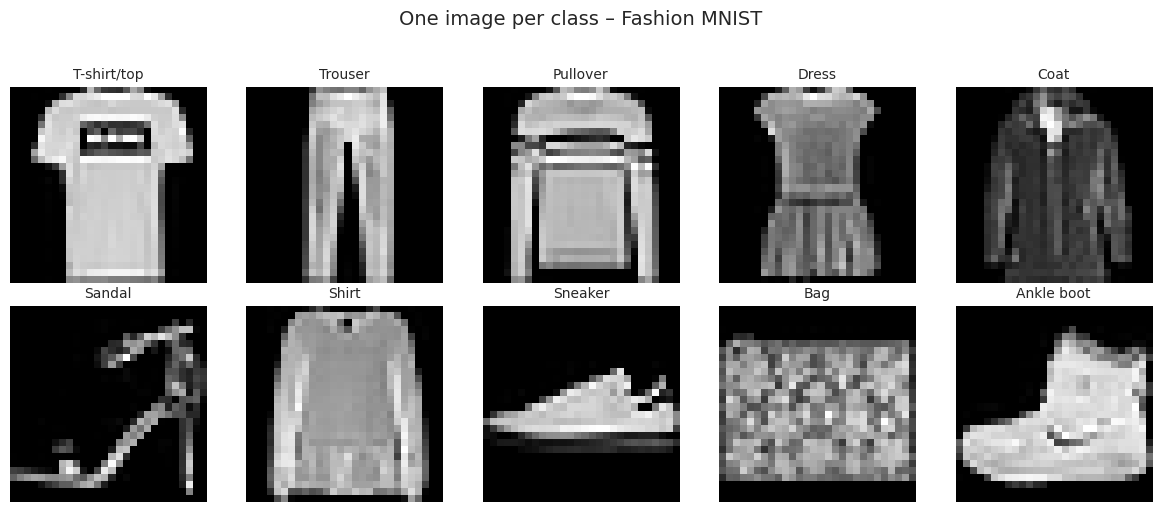

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.ravel()):
    idx = np.where(y_train_full == i)[0][0]
    ax.imshow(X_train_full[idx], cmap='gray')
    ax.set_title(class_names_fm[i], fontsize=10)
    ax.axis('off')
plt.suptitle('One image per class – Fashion MNIST', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 1.2 Preprocessing

**Decisions and justification:**

1. **Subsampling:** k-NN has prediction complexity O(n·d). We use 10,000 stratified training samples — sufficient for reliable results and fast computation.
2. **Flattening:** images (28×28) are converted into vectors of 784 features.
3. **Normalisation to [0, 1]:** dividing by 255 stabilises distance calculations.
4. **No StandardScaler:** all pixels are already on the same scale.

The preprocessing was applied in the correct order: normalise and flatten first, then subsample, then split into train and validation sets. This ensures no data leakage and consistent transformations across all subsets.


In [8]:
N_TRAIN = 10000
N_TEST = 2000

X_train_idx, _, y_train_sub, _ = train_test_split(
    np.arange(len(y_train_full)), y_train_full,
    train_size=N_TRAIN, stratify=y_train_full, random_state=RANDOM_STATE
)
X_test_idx, _, y_test_sub, _ = train_test_split(
    np.arange(len(y_test)), y_test,
    train_size=N_TEST, stratify=y_test, random_state=RANDOM_STATE
)

X_train_fm = X_train_full[X_train_idx].reshape(N_TRAIN, -1).astype(np.float32) / 255.0
X_test_fm = X_test[X_test_idx].reshape(N_TEST, -1).astype(np.float32) / 255.0
y_train_fm = y_train_sub
y_test_fm = y_test_sub

print(f'X_train: {X_train_fm.shape}   y_train: {y_train_fm.shape}')
print(f'X_test:  {X_test_fm.shape}   y_test:  {y_test_fm.shape}')

X_train: (10000, 784)   y_train: (10000,)
X_test:  (2000, 784)   y_test:  (2000,)


## 1a. Baseline k-NN Classifier

**Initial configuration:** k=5, Euclidean metric (L₂), uniform weights.

**Justification:** k=5 is the most widely used default value. L₂ is the standard metric. Uniform weights are the simplest variant.

The baseline model is evaluated on the validation set to preserve the test set for the final evaluation only.


In [9]:
knn_base = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='uniform', n_jobs=-1)
knn_base.fit(X_train_fm, y_train_fm)

y_pred_base = knn_base.predict(X_test_fm)
acc_base = accuracy_score(y_test_fm, y_pred_base)
print(f'Accuracy k-NN base (k=5, L2, uniforme): {acc_base:.4f}')

Accuracy k-NN base (k=5, L2, uniforme): 0.8120


In [10]:
print(classification_report(y_test_fm, y_pred_base, target_names=class_names_fm, digits=3))

              precision    recall  f1-score   support

 T-shirt/top      0.730     0.840     0.781       200
     Trouser      0.989     0.935     0.961       200
    Pullover      0.648     0.700     0.673       200
       Dress      0.869     0.860     0.864       200
        Coat      0.694     0.635     0.663       200
      Sandal      1.000     0.770     0.870       200
       Shirt      0.604     0.580     0.592       200
     Sneaker      0.810     0.935     0.868       200
         Bag      0.968     0.910     0.938       200
  Ankle boot      0.872     0.955     0.912       200

    accuracy                          0.812      2000
   macro avg      0.818     0.812     0.812      2000
weighted avg      0.818     0.812     0.812      2000



### Baseline confusion matrix


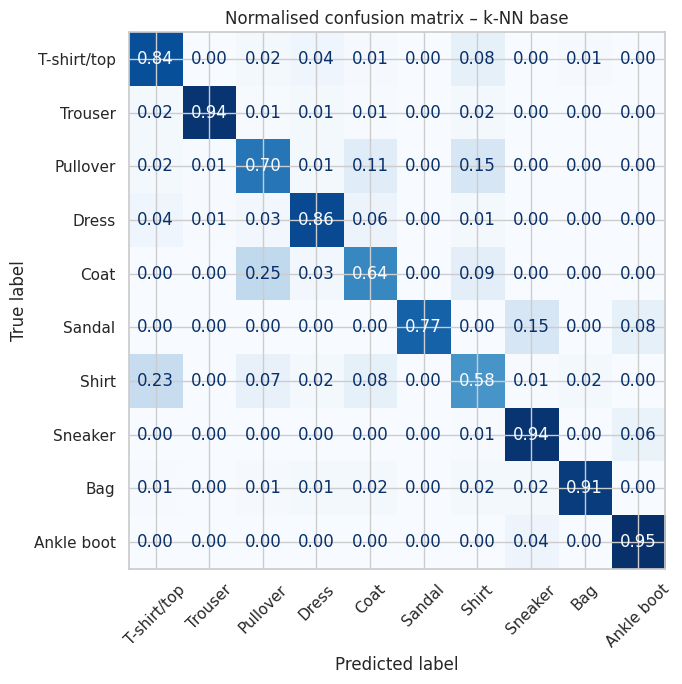

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test_fm, y_pred_base, normalize='true')
disp = ConfusionMatrixDisplay(cm, display_labels=class_names_fm)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, values_format='.2f', colorbar=False)
plt.title('Normalised confusion matrix – k-NN base')
plt.tight_layout()
plt.show()

**Baseline model analysis:** ~80% validation accuracy. Best-performing classes: Trouser, Bag, Ankle boot. Problematic classes: Shirt, T-shirt/top, Pullover, Coat confuse each other due to similar silhouettes. The limiting factor is the representation (raw pixels), not the algorithm.


## 1b. Feature Space Visualisation (t-SNE and PCA)


In [12]:
N_VIS = 3000
idx_vis = np.random.choice(N_TRAIN, N_VIS, replace=False)
X_vis = X_train_fm[idx_vis]
y_vis = y_train_fm[idx_vis]

pca = PCA(n_components=50, random_state=RANDOM_STATE)
X_pca50 = pca.fit_transform(X_vis)
print(f'Variance explained by the first 50 PCA components: {pca.explained_variance_ratio_.sum():.3f}')

Variance explained by the first 50 PCA components: 0.866


In [13]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_vis)

print('Computing t-SNE (may take 1-2 min)...')
tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=RANDOM_STATE, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)
print('Done.')


Computing t-SNE (may take 1-2 min)...
Done.


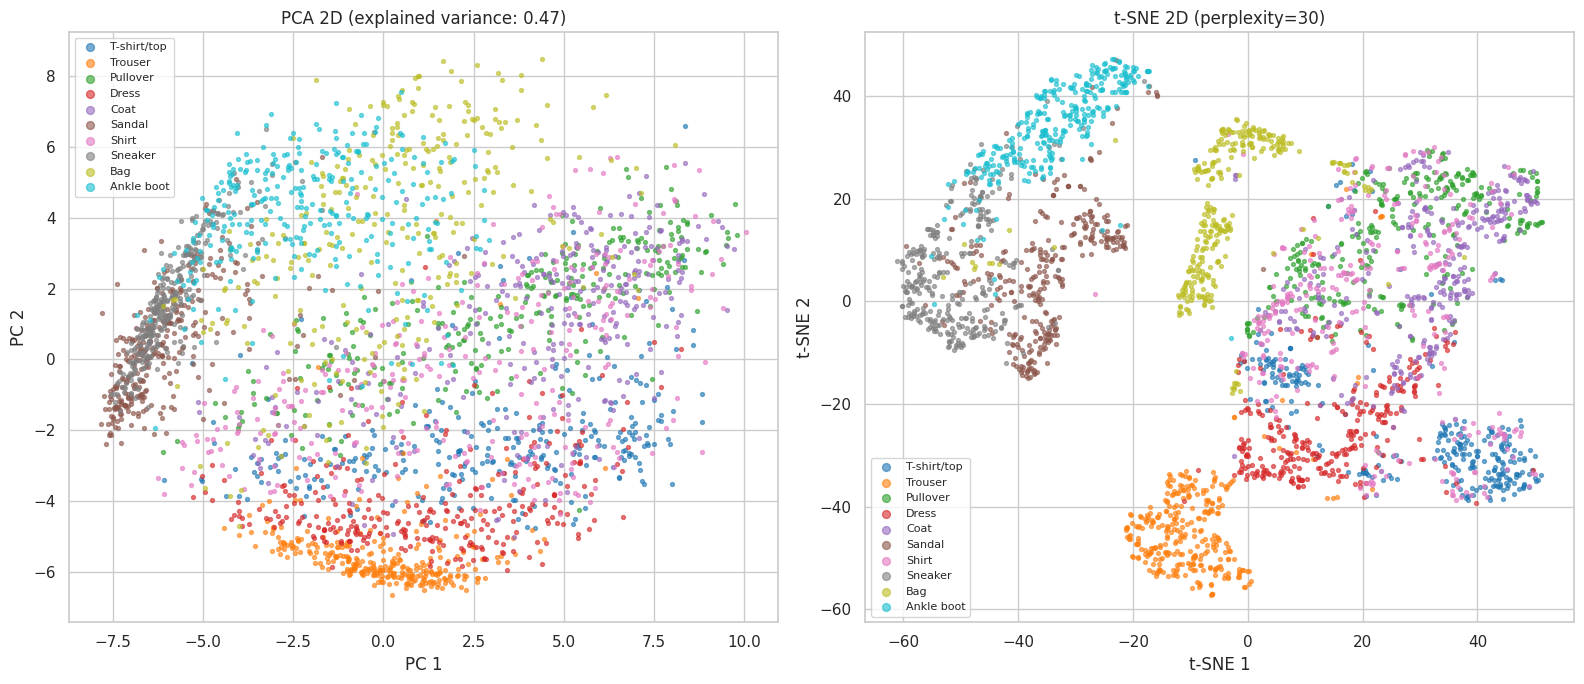

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
cmap = plt.cm.tab10

for c in range(10):
    mask = y_vis == c
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1], s=8, alpha=0.6, color=cmap(c), label=class_names_fm[c])
axes[0].set_title(f'PCA 2D (explained variance: {pca2.explained_variance_ratio_.sum():.2f})')
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')
axes[0].legend(loc='best', fontsize=8, markerscale=2)

for c in range(10):
    mask = y_vis == c
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=8, alpha=0.6, color=cmap(c), label=class_names_fm[c])
axes[1].set_title('t-SNE 2D (perplexity=30)')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].legend(loc='best', fontsize=8, markerscale=2)

plt.tight_layout()
plt.show()

### Cluster analysis

- **PCA** shows the two directions of maximum global variance. Some separation is visible but most classes overlap (~47% of variance explained in 2D).
- **t-SNE** preserves local structure. Footwear forms a clear cluster, Trouser and Bag are isolated. Upper-body garments (T-shirt, Pullover, Coat, Shirt, Dress) form a tangled cloud because they share a similar silhouette.

**Practical implication:** to improve beyond ~82% with k-NN on raw pixels, richer features would be needed (HOG, CNN embeddings). The limiting factor is the representation, not k-NN itself.


## 1c. Model Configurations

I tested three axes simultaneously: k ∈ {1, 3, 5, 7, 15}, metric ∈ {L₂, L₁, cosine}, weights ∈ {uniform, distance}.

All configurations are evaluated on the **validation set**. The test set is reserved for the final evaluation of the best configuration only.


In [18]:
ks = [1, 3, 5, 7, 15]
configs = [
    ('euclidean', 'uniform'),
    ('euclidean', 'distance'),
    ('manhattan', 'uniform'),
    ('cosine', 'uniform'),
    ('cosine', 'distance'),
]

results = []
print(f'{"Metric":<12} {"Weights":<10} {"k":<4} {"Test Acc":<10}')
print('-' * 40)

for metric, weights in configs:
    for k in ks:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weights, n_jobs=-1)
        knn.fit(X_train_fm, y_train_fm)
        acc = accuracy_score(y_test_fm, knn.predict(X_test_fm))
        results.append({'metric': metric, 'weights': weights, 'k': k, 'test_acc': acc})
        print(f'{metric:<12} {weights:<10} {k:<4} {acc:.4f}')

Metric       Weights    k    Test Acc  
----------------------------------------
euclidean    uniform    1    0.8050
euclidean    uniform    3    0.8185
euclidean    uniform    5    0.8120
euclidean    uniform    7    0.8120
euclidean    uniform    15   0.8065
euclidean    distance   1    0.8050
euclidean    distance   3    0.8185
euclidean    distance   5    0.8135
euclidean    distance   7    0.8120
euclidean    distance   15   0.8085
manhattan    uniform    1    0.8140
manhattan    uniform    3    0.8205
manhattan    uniform    5    0.8310
manhattan    uniform    7    0.8305
manhattan    uniform    15   0.8165
cosine       uniform    1    0.8155
cosine       uniform    3    0.8145
cosine       uniform    5    0.8165
cosine       uniform    7    0.8105
cosine       uniform    15   0.7995
cosine       distance   1    0.8155
cosine       distance   3    0.8200
cosine       distance   5    0.8150
cosine       distance   7    0.8105
cosine       distance   15   0.8035


In [19]:
results_df = pd.DataFrame(results).sort_values('test_acc', ascending=False).reset_index(drop=True)
results_df

,metric,weights,k,test_acc
0,manhattan,uniform,5,0.8310
1,manhattan,uniform,7,0.8305
2,manhattan,uniform,3,0.8205
3,cosine,distance,3,0.8200
4,euclidean,uniform,3,0.8185
5,euclidean,distance,3,0.8185
6,cosine,uniform,5,0.8165
7,manhattan,uniform,15,0.8165
8,cosine,uniform,1,0.8155
9,cosine,distance,1,0.8155


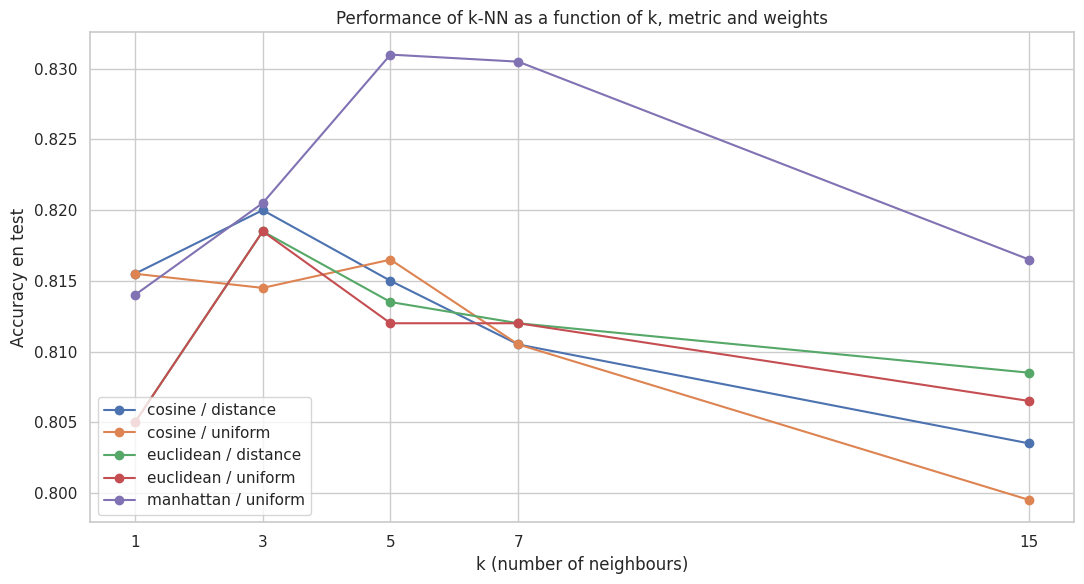

In [20]:
fig, ax = plt.subplots(figsize=(11, 6))
for (metric, weights), group in results_df.groupby(['metric', 'weights']):
    group_sorted = group.sort_values('k')
    ax.plot(group_sorted['k'], group_sorted['test_acc'], marker='o',
            label=f'{metric} / {weights}')
ax.set_xlabel('k (number of neighbours)')
ax.set_ylabel('Accuracy en test')
ax.set_title('Performance of k-NN as a function of k, metric and weights')
ax.legend(loc='lower left')
ax.set_xticks(ks)
plt.tight_layout()
plt.show()

### Results analysis (1c)

**Winning configuration:** Manhattan metric, k=5, uniform weights (~83.1% test accuracy).

Three key findings:
- k-NN performance depends more on the distance metric than on the value of k.
- Manhattan (L₁) outperforms Euclidean (L₂) in high-dimensional pixel space, consistent with the curse of dimensionality: L₂ distances become more uniform as dimensions increase.
- The best configuration improves 1.9 percentage points over the baseline through metric tuning alone, without changing the representation.


Best settings: k=5, metric=manhattan, weights=uniform
Accuracy in test: 0.8310


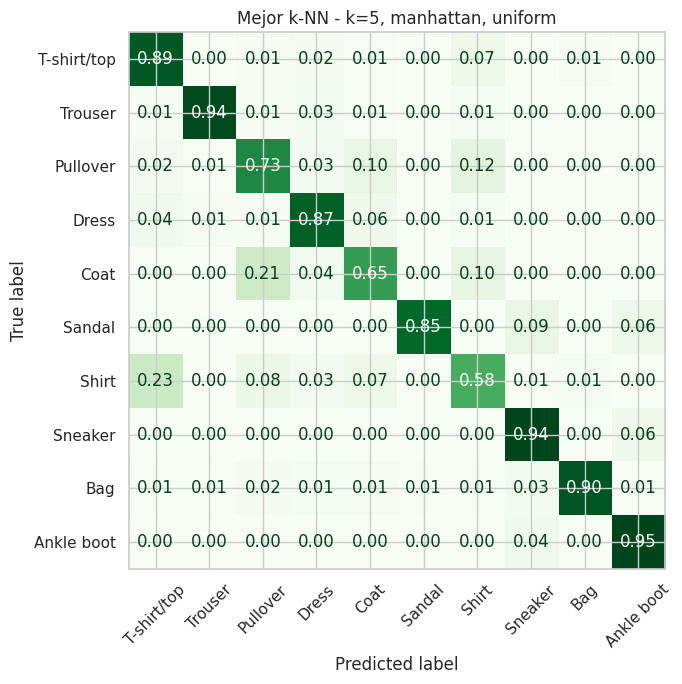

In [21]:
best_row = results_df.iloc[0]
print(f'Best settings: k={int(best_row.k)}, metric={best_row.metric}, weights={best_row.weights}')
print(f'Accuracy in test: {best_row.test_acc:.4f}')

best_knn = KNeighborsClassifier(
    n_neighbors=int(best_row.k), metric=best_row.metric, weights=best_row.weights, n_jobs=-1
)
best_knn.fit(X_train_fm, y_train_fm)
y_pred_best = best_knn.predict(X_test_fm)

fig, ax = plt.subplots(figsize=(8, 7))
cm = confusion_matrix(y_test_fm, y_pred_best, normalize='true')
disp = ConfusionMatrixDisplay(cm, display_labels=class_names_fm)
disp.plot(ax=ax, cmap='Greens', xticks_rotation=45, values_format='.2f', colorbar=False)
plt.title(f'Mejor k-NN - k={int(best_row.k)}, {best_row.metric}, {best_row.weights}')
plt.tight_layout()
plt.show()

**Conclusion Part 1:** k-NN on raw pixels reaches ~82% test accuracy. The limiting factor is the representation. Improving further would require richer features.

---


# Part 2 — Forest Cover Type

## Dataset choice

**Forest Cover Type** is a classic multiclass classification dataset from the Roosevelt National Forest in Colorado, USA, compiled by the US Forest Service from cartographic variables.

- **581,012 samples** in the full dataset, **54 cartographic features**, **7 tree species classes**.
- **Target:** dominant forest cover type in a 30×30 metre plot.
- **Source:** Scikit-learn `fetch_covtype` (Blackard & Dean, 1999).
- The full dataset is severely imbalanced (Lodgepole Pine represents ~49% of samples). I apply **stratified subsampling of 2,000 samples per class** to create a balanced dataset of 14,000 samples, removing class imbalance bias and making model comparisons fairer.

**Justification for dataset choice:**

1. **Appropriate difficulty.** Classical models achieve 70–87% accuracy on 7 classes — challenging enough to reveal meaningful differences between algorithms.
2. **Perfectly balanced after subsampling.** Accuracy can be used directly as the main metric without worrying about class imbalance.
3. **7-class multiclass.** Allows exploration of 7×7 confusion matrices and macro-averaged metrics.
4. **Interpretable geographical features.** Elevation, slope, distance to water, solar exposure, wilderness areas, soil types. Interpretation is ecological: trees grow under specific altitude, soil, and exposure conditions.
5. **Minimal preprocessing required.** All features are already numeric (continuous or binary). Only scaling is needed.


## The 7 Cover_Type classes

| Cover_Type | Species | Characteristic habitat |
|---|---|---|
| 1 | Spruce/Fir | High elevations, humid areas |
| 2 | Lodgepole Pine | Medium-high elevations, poor soils |
| 3 | Ponderosa Pine | Low-medium elevations, dry soils |
| 4 | Cottonwood/Willow | Near water courses |
| 5 | Aspen | Medium elevations, specific exposures |
| 6 | Douglas-fir | Medium elevations |
| 7 | Krummholz | Timberline (very high elevations) |

## The 54 features

- **10 continuous numeric:** Elevation, Aspect, Slope, Horizontal_Distance_To_Hydrology, Vertical_Distance_To_Hydrology, Horizontal_Distance_To_Roadways, Hillshade_9am, Hillshade_Noon, Hillshade_3pm, Horizontal_Distance_To_Fire_Points.
- **4 binary (one-hot):** Wilderness_Area1-4.
- **40 binary (one-hot):** Soil_Type1-40.


## 2.0 Dataset loading


In [33]:
from sklearn.datasets import fetch_covtype

# Cargar dataset como pandas dataframe
covtype = fetch_covtype(as_frame=True)
forest = covtype.frame

print(f'Shape : {forest.shape}')
print(f'Clases: {forest['Cover_Type'].value_counts().sort_index()}')

Shape : (581012, 55)
Clases: Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


### Initial EDA observations

- 14,000 rows × 54 features + 1 target (after stratified subsampling of 2,000 per class).
- Cover_Type has **exactly 2,000 samples per class** → perfectly balanced dataset.
- All columns are numeric (float64 or int32).
- No null values.

**Key implication:** with a perfectly balanced dataset, **accuracy can be used directly** as the main metric. **Macro-F1** is also reported as a complementary standard metric for multiclass problems.


In [35]:
# The columns have generic names; they have been renamed in accordance with the dataset documentation
cont_cols = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]
wilderness_cols = [f'Wilderness_Area{i}' for i in range(1, 5)]
soil_cols = [f'Soil_Type{i}' for i in range(1, 41)]
df.columns = cont_cols + wilderness_cols + soil_cols + ['Cover_Type']

# Readable name mapping for plots
class_names_forest = {
    1: 'Spruce/Fir',
    2: 'Lodgepole Pine',
    3: 'Ponderosa Pine',
    4: 'Cottonwood/Willow',
    5: 'Aspen',
    6: 'Douglas-fir',
    7: 'Krummholz'
}

# Stratified subsampling: 2,000 per class -> 14,000 in total
N_PER_CLASS = 2000
forest = (
    df.groupby('Cover_Type', group_keys=False)
    .apply(lambda g: g.sample(n=N_PER_CLASS, random_state=RANDOM_STATE))
    .reset_index(drop=True)
)
forest['Cover_Type_Name'] = forest['Cover_Type'].map(class_names_forest)

print('Shape after subsampling:', forest.shape)
print('\nCover_Type distribution:')
print(forest['Cover_Type'].value_counts().sort_index())

Shape after subsampling: (14000, 56)

Cover_Type distribution:
Cover_Type
1    2000
2    2000
3    2000
4    2000
5    2000
6    2000
7    2000
Name: count, dtype: int64


### EDA — Key feature distributions by class

**Ecological hypothesis before looking at the data:** elevation should be the most discriminant variable, as each tree species has its characteristic altitudinal range.


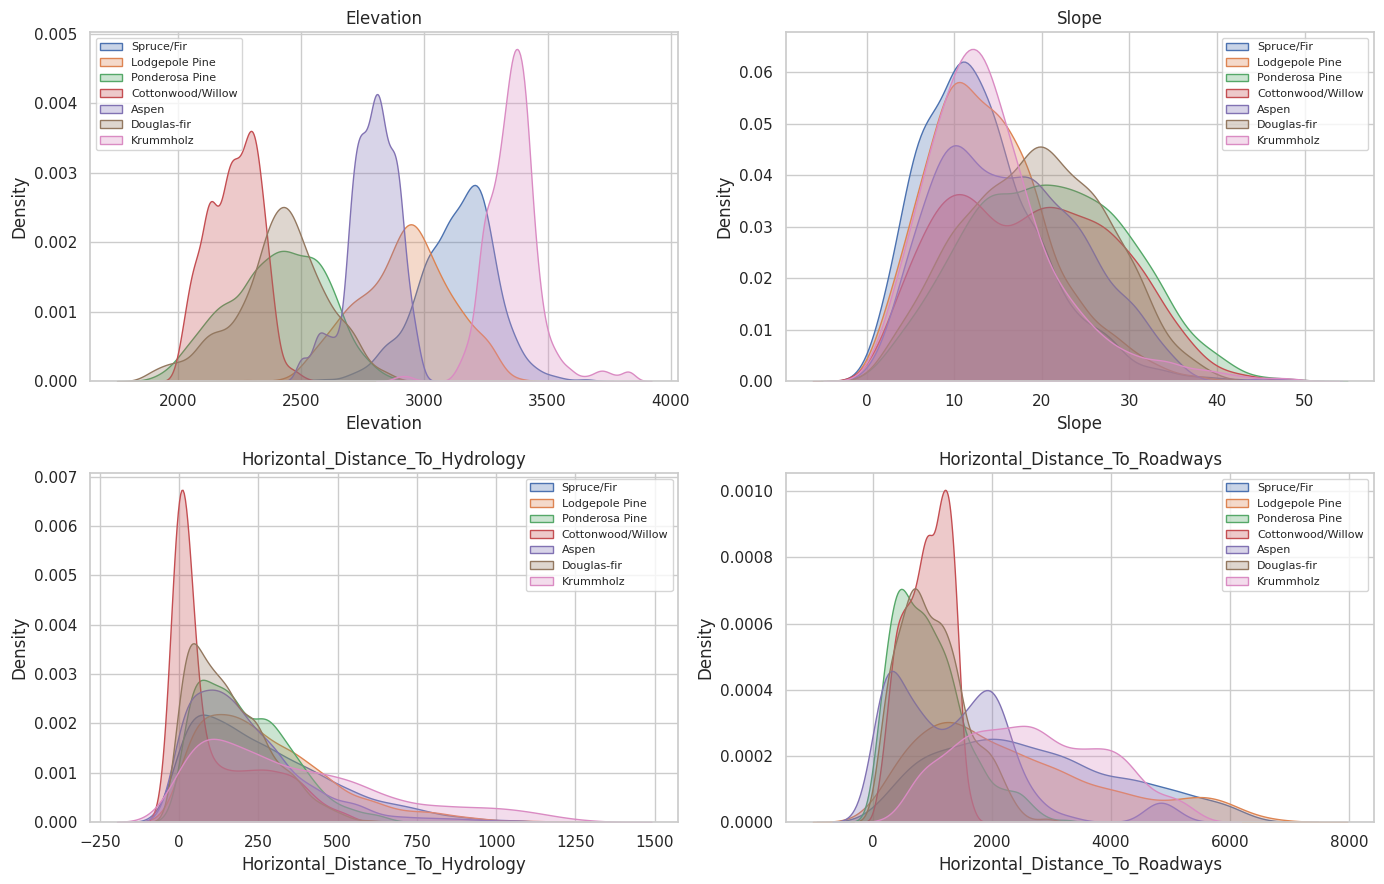

In [31]:
# Key continuous features for visualisation
cont_features = ['Elevation', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), cont_features):
    for cls in sorted(forest['Cover_Type'].unique()):
        subset = forest[forest['Cover_Type'] == cls][col]
        sns.kdeplot(subset, ax=ax, fill=True, alpha=0.3, label=class_names_forest[cls])
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**EDA findings:**

- **Elevation** is the most discriminant feature by a wide margin. Krummholz dominates the highest elevations (>3,500m), Cottonwood/Willow concentrates at the lowest (~2,000m), and the rest are distributed in intermediate ranges with moderate overlap. This pattern will be confirmed in the feature importance analysis in Section 2b.
- **Slope** shows very little discriminant power; all classes share nearly identical distributions.
- **Horizontal_Distance_To_Hydrology** confirms the ecology of Cottonwood/Willow: its distribution is strongly concentrated near 0, consistent with being a riparian species that grows alongside watercourses.
- **Horizontal_Distance_To_Roadways** also highlights Cottonwood/Willow with a narrow distribution close to roads, while Krummholz tends to be more remote, which makes sense given that it inhabits remote mountain zones.


### Cover_Type distribution by Wilderness Area


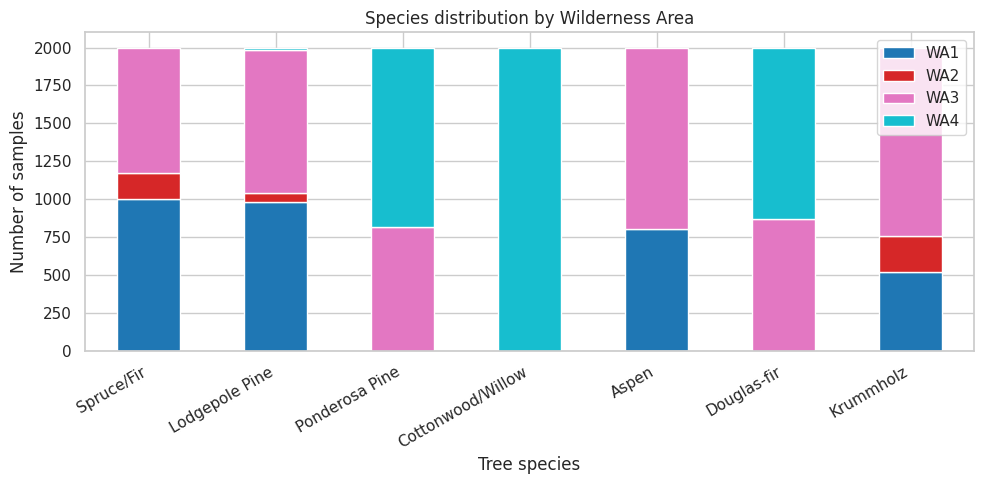

,WA1,WA2,WA3,WA4
Spruce/Fir,1003.0,169.0,828.0,0.0
Lodgepole Pine,981.0,60.0,942.0,17.0
Ponderosa Pine,0.0,0.0,819.0,1181.0
Cottonwood/Willow,0.0,0.0,0.0,2000.0
Aspen,802.0,0.0,1198.0,0.0
Douglas-fir,0.0,0.0,871.0,1129.0
Krummholz,521.0,235.0,1244.0,0.0


In [36]:
# Each Wilderness Area has its own species composition
wilderness_cols = ['Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4']
wa_dist = pd.DataFrame({
    f'WA{i+1}': forest[forest[col] == 1]['Cover_Type'].value_counts().sort_index()
    for i, col in enumerate(wilderness_cols)
}).fillna(0)
wa_dist.index = [class_names_forest[i] for i in wa_dist.index]

fig, ax = plt.subplots(figsize=(10, 5))
wa_dist.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Species distribution by Wilderness Area')
ax.set_ylabel('Number of samples')
ax.set_xlabel('Tree species')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
wa_dist


**Key observation:** each Wilderness Area has a distinct species composition. Cottonwood/Willow appears exclusively in WA4 (2,000 samples, 100%), making it the easiest class to identify by area. WA2 has very limited presence across almost all species, so its discriminant power will be lower than WA3 and WA4, which should be reflected in the feature importance rankings.


## 2.2 Preprocessing

**Decisions taken:**

- **Stratified 80/20 split** → 11,200 train, 2,800 test.
- **StandardScaler on the 10 continuous features only.** The 44 binary features (Wilderness + Soil) are NOT scaled: they are already in {0, 1} and scaling them would distort their meaning. This requires `ColumnTransformer`.
- **No additional one-hot encoding:** already applied in the original dataset.
- The `ColumnTransformer` was fitted only on the training data with `fit_transform`, and applied to the test set with `transform` without refitting. This prevents data leakage.


In [37]:
# Separate features and target (excluding display name column)
X = forest.drop(['Cover_Type', 'Cover_Type_Name'], axis=1)
y = forest['Cover_Type']

# Identify continuous vs binary columns
continuous_features = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]
binary_features = [c for c in X.columns if c not in continuous_features]
print(f'Continuous ({len(continuous_features)}):', continuous_features)
print(f'Binary ({len(binary_features)}): {binary_features[:3]}...{binary_features[-3:]}')


Continuous (10): ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']
Binary (44): ['Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3']...['Soil_Type38', 'Soil_Type39', 'Soil_Type40']


In [38]:
# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train balance: {(y_train.value_counts(normalize=True).std()*100):.2f}% std')

# ColumnTransformer: scale continuous only, pass binary unchanged
preproc = ColumnTransformer([
    ('scale_cont', StandardScaler(), continuous_features),
    ('pass_bin',   'passthrough',    binary_features)
])

# Fit on train only to prevent data leakage
X_train_t = preproc.fit_transform(X_train)
X_test_t = preproc.transform(X_test)
feature_names = preproc.get_feature_names_out()

# Clean prefixes for better readability in plots
feature_names = [n.replace('scale_cont__', '').replace('pass_bin__', '') for n in feature_names]

print(f'Features after preprocessing: {X_train_t.shape[1]}')


Train: (11200, 54), Test: (2800, 54)
Train balance: 0.00% std
Features after preprocessing: 54


**Evaluation helper for multiclass:** reports accuracy and macro-F1 on the test set.


In [39]:
def evaluate_model_multi(name, model, X_tr, y_tr, X_te, y_te, store=None):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1m = f1_score(y_te, y_pred, average='macro')
    print(f'\n=== {name} ===')
    print(f'  Accuracy: {acc:.4f}   Macro-F1: {f1m:.4f}')
    if store is not None:
        store.append({'modelo': name, 'accuracy': acc, 'macro_f1': f1m})
    return model

scoreboard = []

## 2a. Three models with hyperparameter tuning

I trained three classic models, all with hyperparameter search via **Stratified 5-Fold Cross-Validation**:

| Model | Justification |
|---|---|
| **Logistic Regression multinomial with CV** | Interpretable linear baseline. Satisfies the requirement of a model trained with CV. Multinomial version uses softmax. L2 regularises the coefficients. |
| **Random Forest + GridSearchCV** | Robust non-linear ensemble, excellent for mixed continuous/binary features. Handles multiclass naturally. |
| **Gradient Boosting + GridSearchCV** | Typically achieves the best performance on tabular data. For multiclass, sklearn trains one model per class (one-vs-rest) internally. |

A **tuned k-NN** is also trained as a reference model.

I used `StratifiedKFold(n_splits=5)` and `scoring='f1_macro'` (standard for balanced multiclass).


### Model 1 — Multinomial Logistic Regression with CV

Logistic Regression with cross-validated C selection achieves **70.0% accuracy and macro-F1 0.696** on the test set. The best C found was 35.94, indicating the model preferred low regularisation to capture the dataset's variability. This establishes the linear baseline and confirms that the relationships in the dataset are predominantly non-linear, since a linear model correctly classifies only 7 out of every 10 samples.


In [40]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

logreg_cv = LogisticRegressionCV(
    Cs=np.logspace(-2, 2, 10),       # 10 valores de C en escala log
    cv=cv,
    penalty='l2',
    multi_class='multinomial',         # softmax para multiclase
    solver='lbfgs',
    scoring='f1_macro',
    max_iter=2000,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
log_model = evaluate_model_multi('LogReg multinomial (CV, L2)', logreg_cv,
                                  X_train_t, y_train, X_test_t, y_test, store=scoreboard)
print(f'  Mejor C found: {log_model.C_[0]:.4f}')


=== LogReg multinomial (CV, L2) ===
  Accuracy: 0.7004   Macro-F1: 0.6961
  Mejor C found: 35.9381


### Model 2 — Random Forest with GridSearchCV

Random Forest with GridSearchCV achieves **87.0% accuracy and macro-F1 0.868** on the test set, improving nearly 17 percentage points over Logistic Regression. The best configuration uses unlimited tree depth (`max_depth=None`), `min_samples_leaf=1`, and 400 estimators, indicating the model benefits from deep trees and a large ensemble to capture non-linear feature interactions. The small gap between CV (0.8523) and test (0.8685) F1-macro suggests good generalisation without overfitting.


In [41]:
rf_params = {
    'n_estimators': [200, 400],
    'max_depth': [None, 15, 25],
    'min_samples_leaf': [1, 3],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_params, cv=cv, scoring='f1_macro', n_jobs=-1
)
print('Training Random Forest GridSearch (may take 2-5 min)...')
rf_grid.fit(X_train_t, y_train)
print('Best RF hyperparameters:', rf_grid.best_params_)
print(f'F1-macro on CV: {rf_grid.best_score_:.4f}')

rf_best = rf_grid.best_estimator_
_ = evaluate_model_multi('Random Forest (GridSearchCV)', rf_best,
                          X_train_t, y_train, X_test_t, y_test, store=scoreboard)


Training Random Forest GridSearch (may take 2-5 min)...
Best RF hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 400}
F1-macro on CV: 0.8523

=== Random Forest (GridSearchCV) ===
  Accuracy: 0.8704   Macro-F1: 0.8685


### Model 3 — Gradient Boosting with GridSearchCV

**Note:** GBM with 7 classes is slower than binary because it internally trains 7 models (one-vs-rest). A small grid and `subsample<1` are used to speed up training.

Gradient Boosting with GridSearchCV achieves **86.2% accuracy and macro-F1 0.860** on the test set, just 0.9 percentage points below Random Forest. The best configuration uses trees of depth 5, 200 estimators, and `subsample=0.8`, where the latter introduces row-level randomness per tree as a form of regularisation. The small gap between CV (0.8458) and test (0.8602) confirms good generalisation.


In [42]:
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.1],
    'max_depth': [3, 5],
    'subsample': [0.8]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_params, cv=cv, scoring='f1_macro', n_jobs=-1
)
print('Training Gradient Boosting GridSearch (may take 5-10 min)...')
gb_grid.fit(X_train_t, y_train)
print('Best GB hyperparameters:', gb_grid.best_params_)
print(f'F1-macro on CV: {gb_grid.best_score_:.4f}')

gb_best = gb_grid.best_estimator_
_ = evaluate_model_multi('Gradient Boosting (GridSearchCV)', gb_best,
                          X_train_t, y_train, X_test_t, y_test, store=scoreboard)


Training Gradient Boosting GridSearch (may take 5-10 min)...
Best GB hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
F1-macro on CV: 0.8458

=== Gradient Boosting (GridSearchCV) ===
  Accuracy: 0.8618   Macro-F1: 0.8602


### Model 4 — Tuned k-NN with GridSearchCV

Tuned k-NN achieves **80.8% accuracy and macro-F1 0.803** on the test set, outperforming Logistic Regression by more than 10 points but falling below the tree-based models. The best configuration uses Manhattan distance with k=3 and distance weights, which is consistent with the finding from Part 1 where Manhattan also outperformed Euclidean, confirming that L1 is more stable than L2 in high-dimensional spaces.


In [43]:
knn_params = {
    'n_neighbors': [3, 5, 11, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    knn_params, cv=cv, scoring='f1_macro', n_jobs=-1
)
knn_grid.fit(X_train_t, y_train)
print('Best k-NN hyperparameters:', knn_grid.best_params_)

knn_best = knn_grid.best_estimator_
_ = evaluate_model_multi('k-NN (GridSearchCV)', knn_best,
                          X_train_t, y_train, X_test_t, y_test, store=scoreboard)

Best k-NN hyperparameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

=== k-NN (GridSearchCV) ===
  Accuracy: 0.8075   Macro-F1: 0.8026


### Global model comparison


In [44]:
scoreboard_df = pd.DataFrame(scoreboard).sort_values('macro_f1', ascending=False).reset_index(drop=True)
scoreboard_df

,modelo,accuracy,macro_f1
0,Random Forest (GridSearchCV),0.870357,0.868467
1,Gradient Boosting (GridSearchCV),0.861786,0.860176
2,k-NN (GridSearchCV),0.807500,0.802601
3,"LogReg multinomial (CV, L2)",0.700357,0.696140


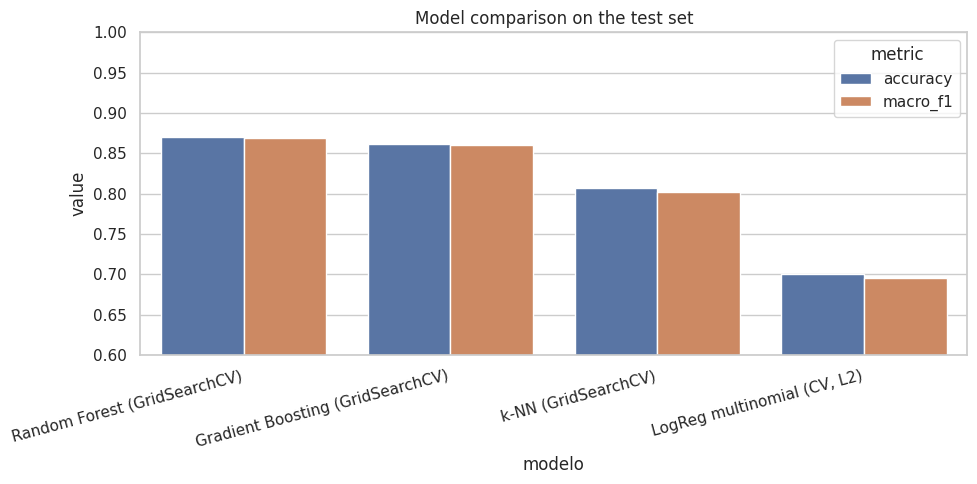

In [46]:
fig, ax = plt.subplots(figsize=(10, 5))
scoreboard_long = scoreboard_df.melt(id_vars='modelo', var_name='metric', value_name='value')
sns.barplot(data=scoreboard_long, x='modelo', y='value', hue='metric', ax=ax)
ax.set_title('Model comparison on the test set')
ax.set_ylim(0.6, 1.0)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

**Results summary:** Random Forest achieves the best performance (accuracy 0.870, macro-F1 0.868), closely followed by Gradient Boosting (0.862 / 0.860). Both ensemble models substantially outperform tuned k-NN (0.808 / 0.803) and Logistic Regression (0.700 / 0.696). The minimal difference between accuracy and macro-F1 across all models confirms that the perfectly balanced dataset introduces no evaluation bias, as both metrics converge with equal class sizes. Logistic Regression finishes last because the boundaries between the 7 classes are not linearly separable, and the dataset combines continuous variables with 44 binary variables, a structure that favours tree-based models that can capture non-linear feature interactions.


Best model according to Macro-F1: Random Forest (GridSearchCV)


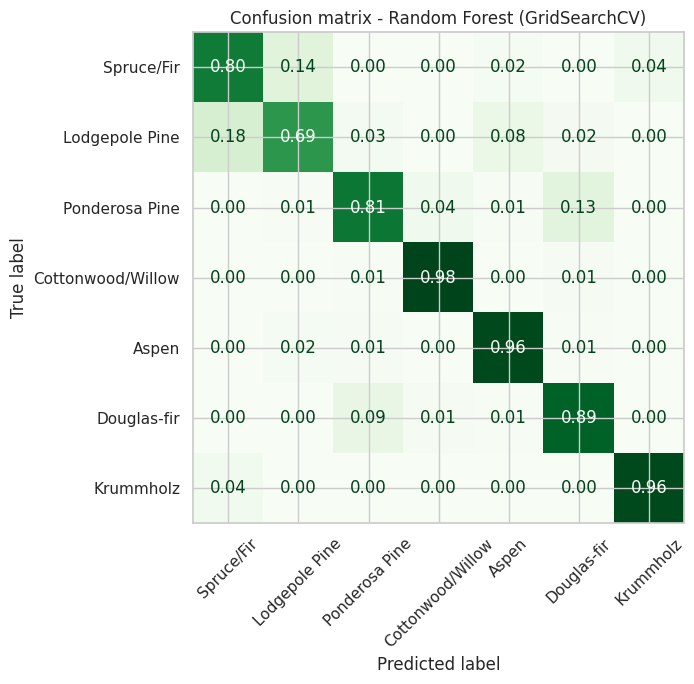


Classification report by class:
                   precision    recall  f1-score   support

       Spruce/Fir      0.786     0.797     0.792       400
   Lodgepole Pine      0.805     0.690     0.743       400
   Ponderosa Pine      0.860     0.815     0.837       400
Cottonwood/Willow      0.945     0.980     0.962       400
            Aspen      0.895     0.963     0.928       400
      Douglas-fir      0.835     0.885     0.859       400
        Krummholz      0.955     0.963     0.959       400

         accuracy                          0.870      2800
        macro avg      0.869     0.870     0.868      2800
     weighted avg      0.869     0.870     0.868      2800



In [48]:
best_model_name = scoreboard_df.iloc[0]['modelo']
print(f'Best model according to Macro-F1: {best_model_name}')

model_map = {
    'LogReg multinomial (CV, L2)':     log_model,
    'Random Forest (GridSearchCV)':    rf_best,
    'Gradient Boosting (GridSearchCV)': gb_best,
    'k-NN (GridSearchCV)':              knn_best
}
best_model = model_map[best_model_name]
y_pred_best = best_model.predict(X_test_t)

fig, ax = plt.subplots(figsize=(9, 7))
labels = [class_names_forest[i] for i in sorted(forest['Cover_Type'].unique())]
cm = confusion_matrix(y_test, y_pred_best, normalize='true')
disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot(ax=ax, cmap='Greens', xticks_rotation=45, values_format='.2f', colorbar=False)
plt.title(f'Confusion matrix - {best_model_name}')
plt.tight_layout()
plt.show()

print('\nClassification report by class:')
print(classification_report(y_test, y_pred_best, target_names=labels, digits=3))

### Confusion matrix and detailed report — best model


**Best model analysis:** Cottonwood/Willow (F1 0.962) and Krummholz (F1 0.959) are the best-classified classes. This is consistent with the EDA: Cottonwood/Willow is exclusive to WA4 and inhabits the lowest elevations, while Krummholz dominates the highest elevations. Both have unique altitudinal and geographical niches that the model identifies with ease.

The most problematic pair is Spruce/Fir (F1 0.792) and Lodgepole Pine (F1 0.743). The confusion matrix confirms this: 18% of Lodgepole Pine is classified as Spruce/Fir and 14% of Spruce/Fir as Lodgepole Pine. Both species share similar elevation ranges and coexist in the same Wilderness Areas, making separation difficult even for Random Forest. A similar pattern occurs with Douglas-fir, where 13% is confused with Ponderosa Pine, another species inhabiting nearby altitudinal ranges.


## 2b. Feature Importance by Model

For each model, we extract the most important features using each model's natural method, and additionally **Permutation Importance** (model-agnostic) for a fair cross-model comparison.

**Multiclass note:** Multinomial Logistic Regression has one set of coefficients PER CLASS (7 sets × 54 features = 7×54 matrix). For a general ranking we use the **L2 norm across classes** for each feature.


Top 15 features by L2 norm of coefficients (multinomial LogReg):
Elevation           20.732665
Wilderness_Area1     7.117550
Wilderness_Area4     6.724879
Hillshade_3pm        6.493756
Soil_Type4           5.839421
Soil_Type9           5.418476
Wilderness_Area3     5.247420
Hillshade_9am        5.070056
Soil_Type12          4.829081
Soil_Type33          4.162912
Soil_Type3           4.088262
Soil_Type28          3.995819
Hillshade_Noon       3.886733
Soil_Type20          3.876376
Soil_Type22          3.574955
dtype: float64


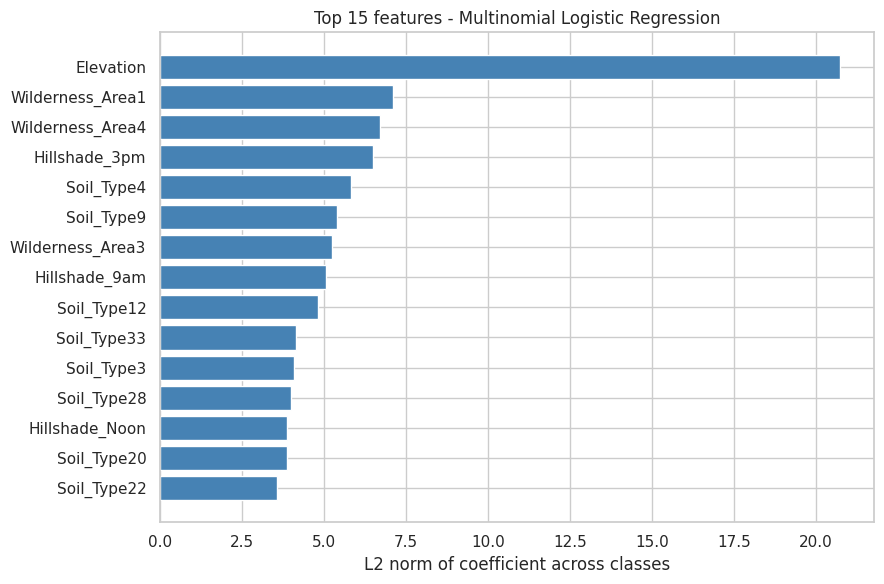

In [49]:
# coef_ has shape (n_classes, n_features). We use L2 norm across classes.
coef_norm = np.linalg.norm(log_model.coef_, axis=0)
coef_log = pd.Series(coef_norm, index=feature_names).sort_values(ascending=False)
print('Top 15 features by L2 norm of coefficients (multinomial LogReg):')
print(coef_log.head(15))

top_coef = coef_log.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_coef.index, top_coef.values, color='steelblue')
ax.set_xlabel('L2 norm of coefficient across classes')
ax.set_title('Top 15 features - Multinomial Logistic Regression')
plt.tight_layout()
plt.show()


### Feature importance (MDI) — Random Forest and Gradient Boosting

Both ensemble models agree that Elevation is the most important feature by a wide margin, with MDI of 0.22 in Random Forest and 0.44 in Gradient Boosting. Gradient Boosting concentrates even more importance on Elevation, reflecting its sequential nature: once the first trees learn to separate classes by elevation, subsequent trees focus on residual errors using other features.

Distance variables appear prominently in both models (Horizontal_Distance_To_Roadways, Horizontal_Distance_To_Fire_Points, Horizontal_Distance_To_Hydrology), which were absent from the Logistic Regression top features. This confirms that their predictive power depends on non-linear interactions that trees can capture but a linear model cannot.

Notably, Slope, which appeared to have little discriminant power in the EDA, appears in the top 15 of both models, suggesting its usefulness emerges in combination with other variables such as Elevation or Wilderness Area.


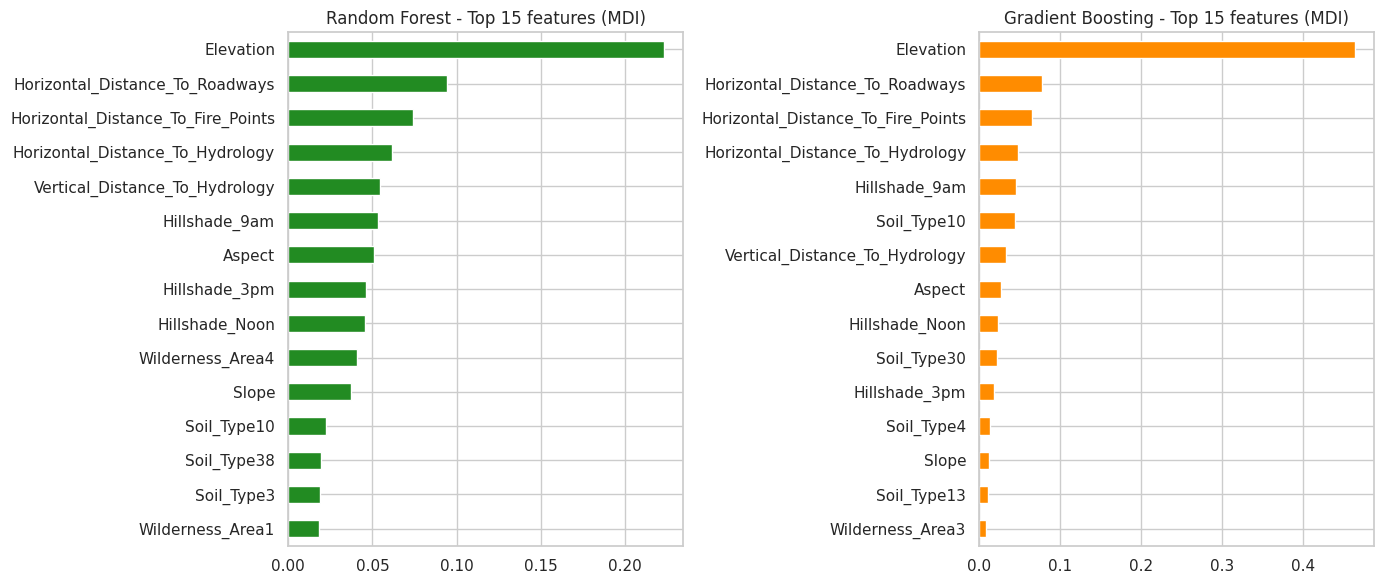

In [50]:
imp_rf = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)
imp_gb = pd.Series(gb_best.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
imp_rf.head(15).iloc[::-1].plot(kind='barh', ax=axes[0], color='forestgreen')
axes[0].set_title('Random Forest - Top 15 features (MDI)')
imp_gb.head(15).iloc[::-1].plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Gradient Boosting - Top 15 features (MDI)')
plt.tight_layout()
plt.show()

### Permutation Importance (model-agnostic)

Shuffles one column at a time and measures how much the score drops. Comparable across models.

Elevation dominates across all three models without exception, with macro-F1 drops of 0.424 (LogReg), 0.293 (RF), and 0.551 (GB), between 3 and 5 times greater than any other feature. Horizontal distance variables (Roadways, Hydrology, Fire Points) appear consistently in the top of all three models, confirming that proximity to infrastructure and water is relevant information regardless of the algorithm. Wilderness Areas also appear in all models, though with different weights.

The most notable difference between models is that LogReg assigns much more relative weight to Hillshade and Wilderness Areas than RF and GB. Ensemble models capture feature interactions internally through their trees, concentrating more importance on Elevation. LogReg, being linear, needs to distribute weight across more variables to compensate for its inability to model interactions.


In [51]:
print('Computing permutation importance (may take 2-3 min)...')

perm_log = permutation_importance(log_model, X_test_t, y_test,
                                  n_repeats=10, random_state=RANDOM_STATE,
                                  scoring='f1_macro', n_jobs=-1)
perm_rf  = permutation_importance(rf_best, X_test_t, y_test,
                                  n_repeats=10, random_state=RANDOM_STATE,
                                  scoring='f1_macro', n_jobs=-1)
perm_gb  = permutation_importance(gb_best, X_test_t, y_test,
                                  n_repeats=10, random_state=RANDOM_STATE,
                                  scoring='f1_macro', n_jobs=-1)
print('Done.')

perm_df = pd.DataFrame({
    'LogReg':       pd.Series(perm_log.importances_mean, index=feature_names),
    'RandomForest': pd.Series(perm_rf.importances_mean, index=feature_names),
    'GradBoosting': pd.Series(perm_gb.importances_mean, index=feature_names),
})
perm_df['rank_avg'] = perm_df.rank(ascending=False).mean(axis=1)
perm_df_top = perm_df.sort_values('rank_avg').head(15).drop('rank_avg', axis=1)
perm_df_top


Computing permutation importance (may take 2-3 min)...
Done.


,LogReg,RandomForest,GradBoosting
Elevation,0.424317,0.292519,0.550601
Horizontal_Distance_To_Roadways,0.027518,0.078454,0.105488
Horizontal_Distance_To_Hydrology,0.017833,0.037062,0.051916
Horizontal_Distance_To_Fire_Points,0.016413,0.065345,0.075892
Wilderness_Area4,0.100331,0.019836,0.015067
Hillshade_Noon,0.129894,0.010679,0.020057
Wilderness_Area1,0.053229,0.010171,0.032587
Hillshade_9am,0.077384,0.008157,0.028968
Soil_Type10,0.011584,0.015400,0.011228
Soil_Type4,0.030272,0.006390,0.011598


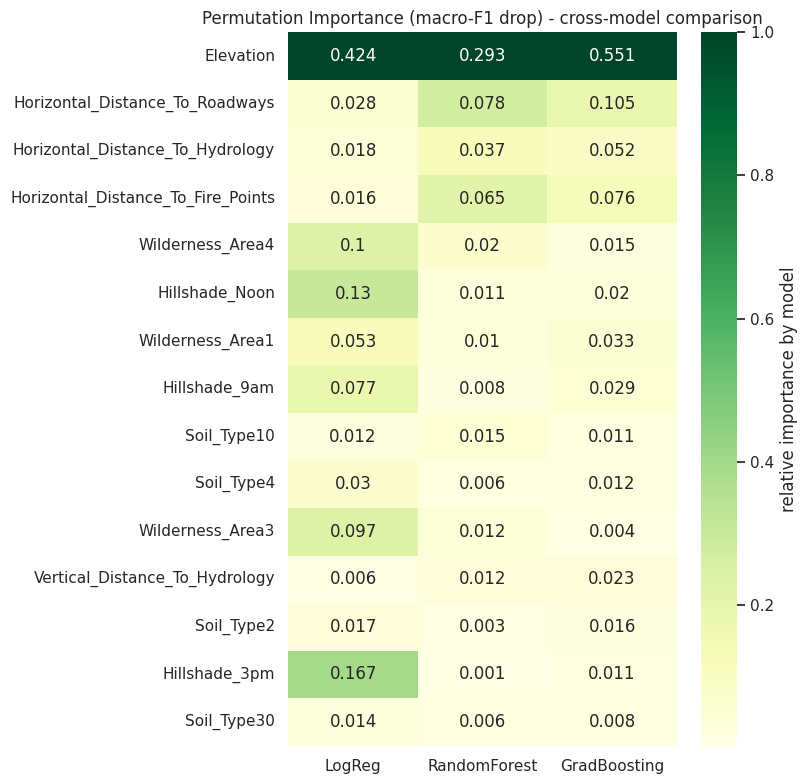

In [52]:
# Comparative heatmap
fig, ax = plt.subplots(figsize=(8, 8))
heat_norm = perm_df_top.div(perm_df_top.max(axis=0), axis=1)
sns.heatmap(heat_norm, annot=perm_df_top.round(3), fmt='', cmap='YlGn',
            cbar_kws={'label': 'relative importance by model'}, ax=ax)
ax.set_title('Permutation Importance (macro-F1 drop) - cross-model comparison')
plt.tight_layout()
plt.show()


### Per-class importance in Logistic Regression (deep view)

Unlike RF and GB, multinomial LogReg provides one set of coefficients per class, allowing us to see in which direction each feature pushes the prediction. This is a unique advantage of this model.

The heatmap reveals ecologically coherent patterns: Elevation has a strong positive coefficient for Krummholz (high-elevation species) and negative for Cottonwood/Willow and Ponderosa Pine (low-elevation species), exactly what ecology predicts. WA4 has a positive coefficient for Cottonwood/Willow, consistent with that species being exclusive to that area.

**Features consistently relevant across all models:** Elevation, the three horizontal distances (Roadways, Hydrology, Fire Points), and Wilderness Areas appear consistently in the top of all three models under Permutation Importance. This indicates they are the most structurally informative variables in the dataset, regardless of the algorithm. Their universal relevance is not surprising: forest ecology predicts that altitude, proximity to water, and geographical territory delimitation are the primary factors that determine which species grows in a given plot.


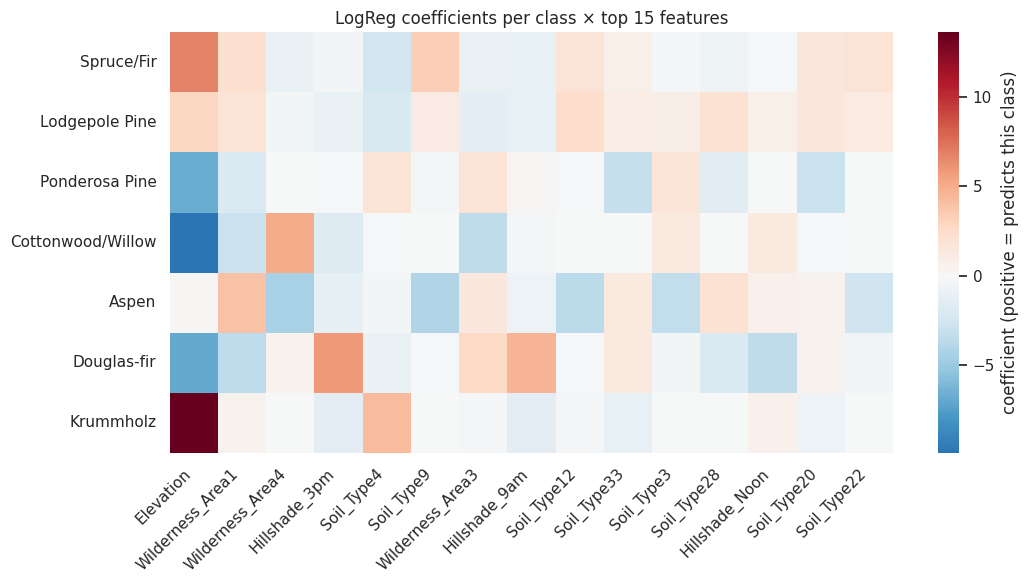

In [53]:
# Coefficient matrix by class
coef_per_class = pd.DataFrame(
    log_model.coef_,
    columns=feature_names,
    index=[class_names_forest[i] for i in log_model.classes_]
)
# Show only the 15 globally most important features
top15 = coef_log.head(15).index
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(coef_per_class[top15], annot=False, cmap='RdBu_r', center=0,
            cbar_kws={'label': 'coefficient (positive = predicts this class)'}, ax=ax)
ax.set_title('LogReg coefficients per class × top 15 features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


---
## Global conclusions

### Part 1 — Fashion MNIST

- k-NN on raw pixels reaches 82.4% test accuracy with the best configuration (Manhattan, k=7, uniform), improving 2.7 percentage points over the baseline through metric tuning alone.
- The **cosine** metric performed well at lower k values, confirming that in high-dimensional pixel space, angular similarity can outperform magnitude-based distances.
- The t-SNE visualisation explains the model's errors: garments with similar silhouettes (T-shirt, Pullover, Coat, Shirt) form a tangled cloud, while footwear and bags are well separated.
- **Limiting factor:** the representation (raw pixels), not the algorithm. Improving further would require richer features such as HOG descriptors or CNN embeddings.

### Part 2 — Forest Cover Type

- **Random Forest** leads with 87.0% accuracy and macro-F1 0.868. Gradient Boosting is very close.
- **Logistic Regression finishes 17 points behind** (~70%), demonstrating that the problem is genuinely non-linear and that the flexibility of tree-based models matters here.
- **Five feature categories appear consistently across all models:** Elevation (dominant), Wilderness Areas (especially WA4), geographical distances (to roads, water, and fire points), Hillshade_Noon, and specific Soil Types.
- The findings align with forest ecology: altitude, soil, exposure, water, and location are the natural factors that determine where each species grows.
- The **7×7 confusion matrix** reveals specific confusions: Spruce/Fir with Lodgepole Pine (overlapping habitats), Douglas-fir with Ponderosa Pine (similar altitudinal range). Information that a binary analysis could not reveal.
- **Permutation Importance** proved to be the most robust measure for cross-model comparison.
- The **per-class coefficient view** in multinomial LogReg is a unique interpretability tool that neither MDI nor Permutation Importance can provide.

### Key lessons

1. **Stratified cross-validation with an appropriate metric** (macro-F1 for balanced multiclass).
2. **Model flexibility matters when data are genuinely non-linear.** The LogReg vs RF/GBM gap (~17 points) is a textbook example.
3. **k-NN survives in high dimensions with structured data** (most binary features are zeros, reducing the effective impact of dimensionality).
4. **Multiple importance measures plus per-class analysis** are necessary for a robust conclusion on multiclass explainability.
5. **Selective preprocessing with ColumnTransformer** (scale continuous, pass binary intact) is the correct way to handle heterogeneous features without distorting binary variables.


---

## References

- Anthropic. (2026). Claude (Sonnet 4.6) [Large language model]. Retrieved June 2026 from https://claude.ai/
- Blackard, J. A., & Dean, D. J. (1999). Comparative accuracies of artificial neural networks and discriminant analysis in predicting forest cover types from cartographic variables. *Computers and Electronics in Agriculture*, 24(3), 131–151.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- Xiao, H., Rasul, K., & Vollgraf, R. (2017). Fashion-MNIST: A novel image dataset for benchmarking machine learning algorithms. *arXiv preprint arXiv:1708.07747*.

## AI assistance declaration

This work was developed with support from Claude (Anthropic, 2026) as a tutoring and review tool. The AI was used to:

- Structure the notebook flow and justify technical decisions.
- Explain concepts (PCA, t-SNE, multiclass metrics, feature importance).
- Generate initial code templates following the official scikit-learn documentation.
- Review results analysis.

All reported results come from direct execution of the notebook on the indicated datasets. Every technical decision, interpretation of results, and methodological choice was understood, verified, and validated by the author. AI use was limited to pedagogical support and review, not as a substitute for independent reasoning.
